In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import datetime
from collections import defaultdict, Counter
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tabulate import tabulate
import hdbscan
from sklearn.metrics import pairwise_distances

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Посмотрим еще раз на данные

In [2]:
data = pd.read_csv('/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/output.csv')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           2001 non-null   int64  
 1   name                         2001 non-null   object 
 2   duration                     2001 non-null   int64  
 3   artist_id                    2001 non-null   int64  
 4   artist_name                  2001 non-null   object 
 5   album_id                     1997 non-null   float64
 6   album_name                   1997 non-null   object 
 7   releasedate                  2001 non-null   object 
 8   waveform                     2000 non-null   object 
 9   musicinfo.vocalinstrumental  1991 non-null   object 
 10  musicinfo.lang               832 non-null    object 
 11  musicinfo.gender             1723 non-null   object 
 12  musicinfo.acousticelectric   1052 non-null   object 
 13  musicinfo.speed   

In [3]:
data.columns[data.isna().any()].to_list()

['album_id',
 'album_name',
 'waveform',
 'musicinfo.vocalinstrumental',
 'musicinfo.lang',
 'musicinfo.gender',
 'musicinfo.acousticelectric',
 'musicinfo.speed']

`Waveform`, `album_id`, `id`, `album_id`, `artist_id` можно выкинуть, не вижу в них полезной информации - айдишники нужны для системы, откуда мы достали аудио, а сейчас пока без надобности

In [4]:
data = data.drop(['waveform', 'album_id', 'id', 'album_id', 'artist_id'], axis=1)

У признаков `musicinfo.lang` и `musicinfo.acousticelectric` ~50% пропусков. Это достаточно большой процент, хотя восстановить все равно можно, но для бейзлайна пока дропнем

In [5]:
data = data.drop(['musicinfo.acousticelectric', 'musicinfo.lang'], axis=1)

In [6]:
data.columns[data.isna().any()].to_list()

['album_name',
 'musicinfo.vocalinstrumental',
 'musicinfo.gender',
 'musicinfo.speed']

У оставшихся столбцов довольно малый процент пропусков (<2%), поэтому можно удалить эти объекты, кроме `musicinfo.gender` - тут процент пропусков уже 13.9%. У нас есть 3 уникальный значения пола - мужской, женский и нейтральный. Предлагаю пока заполнить нейтральным

In [7]:
data = data.dropna(subset=['album_name', 'musicinfo.vocalinstrumental', 'musicinfo.speed'])
data = data.fillna(value={'musicinfo.gender': 'neutral'})
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1974 entries, 0 to 2000
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         1974 non-null   object 
 1   duration                     1974 non-null   int64  
 2   artist_name                  1974 non-null   object 
 3   album_name                   1974 non-null   object 
 4   releasedate                  1974 non-null   object 
 5   musicinfo.vocalinstrumental  1974 non-null   object 
 6   musicinfo.gender             1974 non-null   object 
 7   musicinfo.speed              1974 non-null   object 
 8   musicinfo.tags.genres        1974 non-null   object 
 9   musicinfo.tags.instruments   1974 non-null   object 
 10  musicinfo.tags.vartags       1974 non-null   object 
 11  stats.rate_downloads_total   1974 non-null   int64  
 12  stats.rate_listened_total    1974 non-null   int64  
 13  stats.playlisted       

Давайте закодируем через OHE признаки `musicinfo.vocalinstrumental`, `musicinfo.gender`, `musicinfo.speed`

In [8]:
data = pd.get_dummies(data, columns=['musicinfo.vocalinstrumental', 'musicinfo.gender', 'musicinfo.speed'], drop_first=True)

Теперь переведем дату в таймстемп

In [9]:
data['releasedate'] = data['releasedate'].apply(lambda x: int(datetime.datetime.strptime(x, "%Y-%m-%d").replace(tzinfo=datetime.timezone.utc).timestamp()))

In [10]:
data.head()

,name,duration,artist_name,album_name,releasedate,musicinfo.tags.genres,musicinfo.tags.instruments,musicinfo.tags.vartags,stats.rate_downloads_total,stats.rate_listened_total,...,stats.likes,stats.dislikes,stats.avgnote,musicinfo.vocalinstrumental_vocal,musicinfo.gender_male,musicinfo.gender_neutral,musicinfo.speed_low,musicinfo.speed_medium,musicinfo.speed_veryhigh,musicinfo.speed_verylow
0,Love Too Serious,264,Lilly Wolf,Play Loud,1388966400,"['pop', 'dance', 'synthpop']","['synthesizer', 'drums']","['energetic', 'acoustic', 'vocal', 'voice']",386816,1659776,...,13,2,8.0000,True,False,False,False,True,False,False
1,Girls Like You,198,The Spin Wires,The Spin Wires EP,1501027200,"['rock', 'alternativerock', 'indierock']","['electricguitar', 'bass']","['energetic', 'vocal', 'voice', 'vocalsmale']",147168,1153129,...,0,0,7.6667,True,True,False,False,False,False,False
2,Put That Boy Away,234,Dan Bryk,Discount Store,1208390400,['pop'],[],"['vocal', 'voice']",6878,188773,...,1,1,8.0000,True,True,False,False,True,False,False
3,Epic Music,110,Aliaksei Yukhnevich,Epic Music,1455840000,"['filmscore', 'symphonic']","['strings', 'orchestra']","['epic', 'film', 'cinematic']",97509,374699,...,0,0,9.0000,False,False,True,False,True,False,False
4,Shine,170,Circa Vitae,CIRCA VITAE ep,1228176000,"['rock', 'indierock', 'indie']",['guitar'],"['vocal', 'voice', 'neutral']",22626,1471358,...,2,0,6.5000,True,True,False,False,True,False,False


Эмбеддинги фичей `musicinfo.tags.genres`, `musicinfo.tags.instruments`, `musicinfo.tags.vartags`

In [11]:
model = SentenceTransformer('all-MiniLM-L6-v2')

array_features = [
    'musicinfo.tags.genres',
    'musicinfo.tags.instruments',
    'musicinfo.tags.vartags'
]

def parse_list_string(s):
    if not isinstance(s, str):
        return []
    s = s.strip()
    if len(s) < 2:
        return []
    parts = s[1:-1].replace("'", '').split(',')
    return [p.strip() for p in parts if p.strip()]

def embed_tags(tags, model):
    if not tags:
        tags = ["unknown"]
    return np.mean([model.encode(tag) for tag in tags], axis=0)

embs = defaultdict(list)
for feature in array_features:
    for feature_vals in data[feature]:
        embs[feature].append(embed_tags(parse_list_string(feature_vals), model))


In [12]:
useless_features = ['releasedate', 'album_name', 'artist_name', 'duration', 'name']
test_features = data.drop(useless_features, axis=1)

numeric_features = test_features.select_dtypes(include=['int64', 'float64']).columns.to_list()
encoded_features = test_features.select_dtypes(include='bool').columns.to_list()

print('Numeric', numeric_features)
print('Encoded', encoded_features)
print('Embs', list(embs.keys()))

Numeric ['stats.rate_downloads_total', 'stats.rate_listened_total', 'stats.playlisted', 'stats.favorited', 'stats.likes', 'stats.dislikes', 'stats.avgnote']
Encoded ['musicinfo.vocalinstrumental_vocal', 'musicinfo.gender_male', 'musicinfo.gender_neutral', 'musicinfo.speed_low', 'musicinfo.speed_medium', 'musicinfo.speed_veryhigh', 'musicinfo.speed_verylow']
Embs ['musicinfo.tags.genres', 'musicinfo.tags.instruments', 'musicinfo.tags.vartags']


In [13]:
scaler = MinMaxScaler()

numeric_scaled = scaler.fit_transform(test_features[numeric_features])

In [14]:
features_matrix = np.column_stack((numeric_scaled, test_features[encoded_features].to_numpy(), np.array(list(embs.values())).reshape(1974, 384*3)))

In [15]:
assert features_matrix.shape == (1974, 384 * 3 + 7 * 2)

In [16]:
def compare_objects_from_future_matrix(features, idx1, idx2):
    print(
        cosine_similarity(
            features[idx1].reshape(1, -1),
            features[idx2].reshape(1, -1)
        ),
        ':',
        data['musicinfo.tags.genres'][idx1],
        'X',
        data['musicinfo.tags.genres'][idx2], 
        '|',
        data['musicinfo.tags.instruments'][idx1],
        'X',
        data['musicinfo.tags.instruments'][idx2],
        '|',
        data['musicinfo.tags.vartags'][idx1],
        'X',
        data['musicinfo.tags.vartags'][idx2], 
    )

pairs_to_compare = [(1, 19), (8, 11), (1, 15), (18, 9), (17, 9)]

In [17]:
for pair in pairs_to_compare:
    idx1, idx2 = pair
    compare_objects_from_future_matrix(features_matrix, idx1, idx2)

[[0.57279432]] : ['rock', 'alternativerock', 'indierock'] X ['rock'] | ['electricguitar', 'bass'] X [] | ['energetic', 'vocal', 'voice', 'vocalsmale'] X ['vocal', 'voice']
[[0.83073956]] : ['pop'] X ['rock', 'pop'] | [] X [] | ['acoustic', 'vocal', 'voice'] X ['acoustic', 'vocal', 'voice']
[[0.6540465]] : ['rock', 'alternativerock', 'indierock'] X ['rock', 'alternativerock'] | ['electricguitar', 'bass'] X [] | ['energetic', 'vocal', 'voice', 'vocalsmale'] X ['acoustic', 'vocal', 'voice', 'neutral']
[[0.8488706]] : ['electronic', 'chillout', 'pop'] X ['newage', 'ambient', 'electronic'] | ['synthesizer', 'violin'] X [] | ['musiquedefilm'] X ['peaceful', 'neutral', 'easy']
[[0.76856677]] : ['jazz', 'bebop'] X ['newage', 'ambient', 'electronic'] | ['piano', 'strings'] X [] | ['uprightbass'] X ['peaceful', 'neutral', 'easy']


Косинусное расстояние стало хуже, когда мы все подвели под один вектор. Стали очень похожи между собой `[[0.76856677]] : ['jazz', 'bebop'] | ['newage', 'ambient', 'electronic']`, хотя тут по инструментам и тегам вообще разное настроение - так влияют, скорее всего другие фичи.

Я считаю, что пользователь ожидает, что ему попадется как минимум по жанру трек похожий, а может с похожими инструментами и тегами, также стоит ожидать еще вклад популярности трека. Попробую объеденить только эмбеддинги и нумерик фичи и еще проверить, как себя покажут чисто эмбеддинги

In [18]:
# numeric + embs
features_matrix2 = np.column_stack((numeric_scaled, np.array(list(embs.values())).reshape(1974, 384*3)))

In [19]:
for pair in pairs_to_compare:
    idx1, idx2 = pair
    compare_objects_from_future_matrix(features_matrix2, idx1, idx2)

[[0.62929381]] : ['rock', 'alternativerock', 'indierock'] X ['rock'] | ['electricguitar', 'bass'] X [] | ['energetic', 'vocal', 'voice', 'vocalsmale'] X ['vocal', 'voice']
[[0.67397312]] : ['pop'] X ['rock', 'pop'] | [] X [] | ['acoustic', 'vocal', 'voice'] X ['acoustic', 'vocal', 'voice']
[[0.51638243]] : ['rock', 'alternativerock', 'indierock'] X ['rock', 'alternativerock'] | ['electricguitar', 'bass'] X [] | ['energetic', 'vocal', 'voice', 'vocalsmale'] X ['acoustic', 'vocal', 'voice', 'neutral']
[[0.71627713]] : ['electronic', 'chillout', 'pop'] X ['newage', 'ambient', 'electronic'] | ['synthesizer', 'violin'] X [] | ['musiquedefilm'] X ['peaceful', 'neutral', 'easy']
[[0.58566597]] : ['jazz', 'bebop'] X ['newage', 'ambient', 'electronic'] | ['piano', 'strings'] X [] | ['uprightbass'] X ['peaceful', 'neutral', 'easy']


In [20]:
# embs
features_matrix3 = np.column_stack((np.array(list(embs.values()))))

In [21]:
assert features_matrix3.shape == (1974, 384*3)

In [22]:
for pair in pairs_to_compare:
    idx1, idx2 = pair
    compare_objects_from_future_matrix(features_matrix3, idx1, idx2)

[[0.69355536]] : ['rock', 'alternativerock', 'indierock'] X ['rock'] | ['electricguitar', 'bass'] X [] | ['energetic', 'vocal', 'voice', 'vocalsmale'] X ['vocal', 'voice']
[[0.9538106]] : ['pop'] X ['rock', 'pop'] | [] X [] | ['acoustic', 'vocal', 'voice'] X ['acoustic', 'vocal', 'voice']
[[0.7172525]] : ['rock', 'alternativerock', 'indierock'] X ['rock', 'alternativerock'] | ['electricguitar', 'bass'] X [] | ['energetic', 'vocal', 'voice', 'vocalsmale'] X ['acoustic', 'vocal', 'voice', 'neutral']
[[0.3072631]] : ['electronic', 'chillout', 'pop'] X ['newage', 'ambient', 'electronic'] | ['synthesizer', 'violin'] X [] | ['musiquedefilm'] X ['peaceful', 'neutral', 'easy']
[[0.29870433]] : ['jazz', 'bebop'] X ['newage', 'ambient', 'electronic'] | ['piano', 'strings'] X [] | ['uprightbass'] X ['peaceful', 'neutral', 'easy']


Отдельно эмбеддинги показывают себя очень хорошо, проверим теперь только нумерик фичи

In [23]:
def compare_objects_numeric(idx1, idx2):
    sim_value = cosine_similarity(
        numeric_scaled[idx1].reshape(1, -1),
        numeric_scaled[idx2].reshape(1, -1)
    )[0][0]

    table_data = []
    for feature in numeric_features:
        val1 = data[numeric_features].loc[idx1][feature]
        val2 = data[numeric_features].loc[idx2][feature]
        diff = abs(val1 - val2)
        
        table_data.append([
            feature,
            val1,
            val2,
            diff,
        ])

    headers = ['Признак', f'Объект {idx1}', f'Объект {idx2}', 'Разница']

    print('\n' + '=' * 80)
    print(f'КОСИНУСНОЕ СХОДСТВО МЕЖДУ ОБЪЕКТАМИ {idx1} и {idx2}: {sim_value}')
    print('=' * 80)
    print(tabulate(table_data, headers=headers, tablefmt='grid', floatfmt='.6f'))


for pair in pairs_to_compare:
    idx1, idx2 = pair
    compare_objects_numeric(idx1, idx2)



КОСИНУСНОЕ СХОДСТВО МЕЖДУ ОБЪЕКТАМИ 1 и 19: 0.9980329951288731
+----------------------------+----------------+---------------+---------------+
| Признак                    |       Объект 1 |     Объект 19 |       Разница |
+============================+================+===============+===============+
| stats.rate_downloads_total |  147168.000000 |  97645.000000 |  49523.000000 |
+----------------------------+----------------+---------------+---------------+
| stats.rate_listened_total  | 1153129.000000 | 611754.000000 | 541375.000000 |
+----------------------------+----------------+---------------+---------------+
| stats.playlisted           |     947.000000 |    849.000000 |     98.000000 |
+----------------------------+----------------+---------------+---------------+
| stats.favorited            |     595.000000 |    512.000000 |     83.000000 |
+----------------------------+----------------+---------------+---------------+
| stats.likes                |       0.000000 |      6.0

Видно, что чем меньше разница между фичами, тем они ближе, поэтому можно как-то дополнительно это учитывать при поиске рекомендаций. Можно с отдельным весом, например, учитывать сходство по нумерик фичам. Думаю, что можно даже выкинуть `stats.avgnote`, чтобы у нас данное сходство отвечало только за популярность треков

Ну, и для полноты картины, посмотрим отдельно еще на закодированные фичи

In [24]:
def compare_objects_encoded(idx1, idx2):
    sim_value = cosine_similarity(
        data[encoded_features].loc[idx1].to_numpy().reshape(1, -1),
        data[encoded_features].loc[idx2].to_numpy().reshape(1, -1)
    )[0][0]

    table_data = []
    for feature in encoded_features:
        val1 = data[encoded_features].loc[idx1][feature]
        val2 = data[encoded_features].loc[idx2][feature]

        table_data.append([
            feature,
            val1,
            val2,
        ])

    headers = ['Признак', f'Объект {idx1}', f'Объект {idx2}']

    print('\n' + '=' * 80)
    print(f'КОСИНУСНОЕ СХОДСТВО МЕЖДУ ОБЪЕКТАМИ {idx1} и {idx2}: {sim_value}')
    print('=' * 80)
    print(tabulate(table_data, headers=headers, tablefmt='grid', floatfmt='.6f'))


for pair in pairs_to_compare:
    idx1, idx2 = pair
    compare_objects_encoded(idx1, idx2)



КОСИНУСНОЕ СХОДСТВО МЕЖДУ ОБЪЕКТАМИ 1 и 19: 0.4999999999999999
+-----------------------------------+------------+-------------+
| Признак                           |   Объект 1 |   Объект 19 |
+===================================+============+=============+
| musicinfo.vocalinstrumental_vocal |   1.000000 |    1.000000 |
+-----------------------------------+------------+-------------+
| musicinfo.gender_male             |   1.000000 |    0.000000 |
+-----------------------------------+------------+-------------+
| musicinfo.gender_neutral          |   0.000000 |    0.000000 |
+-----------------------------------+------------+-------------+
| musicinfo.speed_low               |   0.000000 |    0.000000 |
+-----------------------------------+------------+-------------+
| musicinfo.speed_medium            |   0.000000 |    1.000000 |
+-----------------------------------+------------+-------------+
| musicinfo.speed_veryhigh          |   0.000000 |    0.000000 |
+-------------------------

Ну, достаточно ожидаемый, с точки зрения поведения сходства, результат. Оценим его вместе с эмбеддингами

In [25]:
# encoded + embs
features_matrix4 = np.column_stack((test_features[encoded_features].to_numpy(), np.array(list(embs.values())).reshape(1974, 384*3)))

In [26]:
for pair in pairs_to_compare:
    idx1, idx2 = pair
    compare_objects_from_future_matrix(features_matrix4, idx1, idx2)

[[0.5048594]] : ['rock', 'alternativerock', 'indierock'] X ['rock'] | ['electricguitar', 'bass'] X [] | ['energetic', 'vocal', 'voice', 'vocalsmale'] X ['vocal', 'voice']
[[0.8254307]] : ['pop'] X ['rock', 'pop'] | [] X [] | ['acoustic', 'vocal', 'voice'] X ['acoustic', 'vocal', 'voice']
[[0.606176]] : ['rock', 'alternativerock', 'indierock'] X ['rock', 'alternativerock'] | ['electricguitar', 'bass'] X [] | ['energetic', 'vocal', 'voice', 'vocalsmale'] X ['acoustic', 'vocal', 'voice', 'neutral']
[[0.830661]] : ['electronic', 'chillout', 'pop'] X ['newage', 'ambient', 'electronic'] | ['synthesizer', 'violin'] X [] | ['musiquedefilm'] X ['peaceful', 'neutral', 'easy']
[[0.7507948]] : ['jazz', 'bebop'] X ['newage', 'ambient', 'electronic'] | ['piano', 'strings'] X [] | ['uprightbass'] X ['peaceful', 'neutral', 'easy']


Такое сочетание тоже повлияло на оценку в негативную сторону. Можно тоже иметь в виду данные признаки, но использовать их с каким-то весом

In [27]:
import umap


def build_umap(f):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )
    X_umap = reducer.fit_transform(f)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], s=15, color='steelblue')
    plt.title("UMAP Visualization")
    plt.show()

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


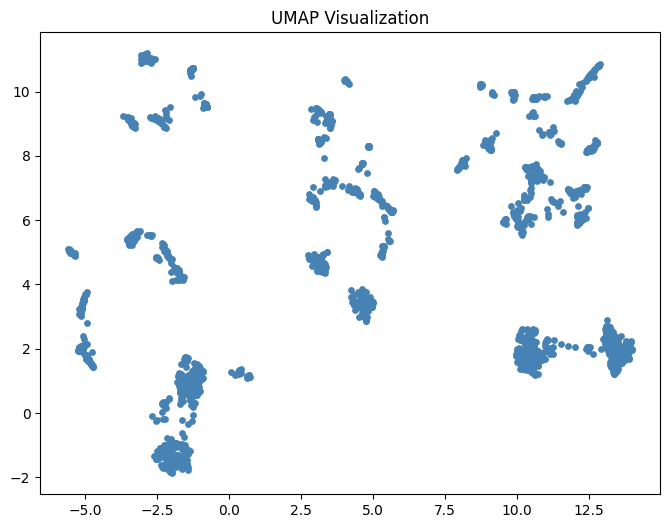

In [28]:
build_umap(features_matrix)

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


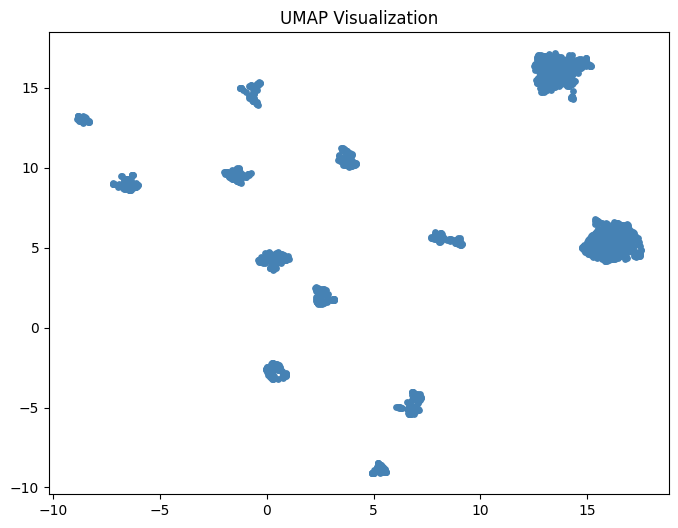

In [29]:
build_umap(features_matrix2)

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


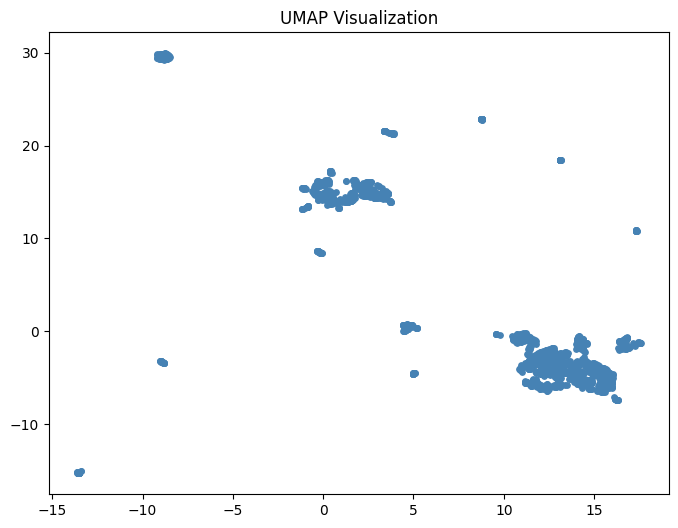

In [30]:
build_umap(features_matrix3)

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


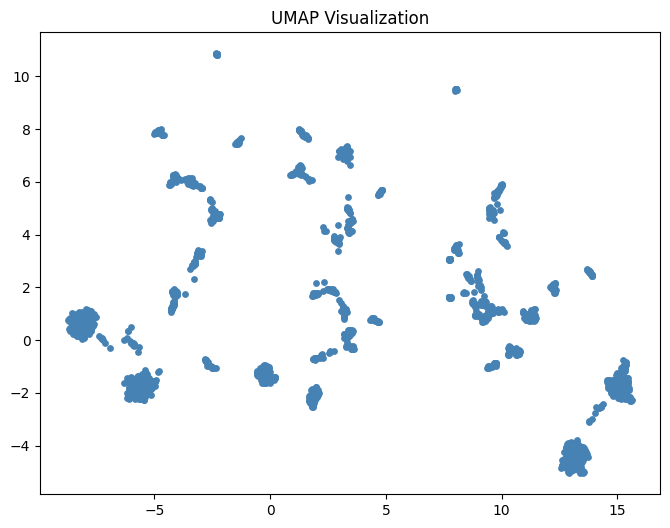

In [31]:
build_umap(features_matrix4)

In [32]:
def cluster_and_visualize_umap_hdbscan(
    X: np.ndarray,
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    min_cluster_size: int = 15
):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        random_state=42
    )
    embedding = reducer.fit_transform(X)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric=lambda a, b: pairwise_distances(a.reshape(1, -1), b.reshape(1, -1), metric="cosine")
    )
    labels = clusterer.fit_predict(embedding)

    plt.figure(figsize=(10, 8))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="Spectral",
        s=10
    )
    plt.colorbar(label="Cluster (−1 = noise)")
    plt.title("UMAP + HDBSCAN clustering")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()



/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


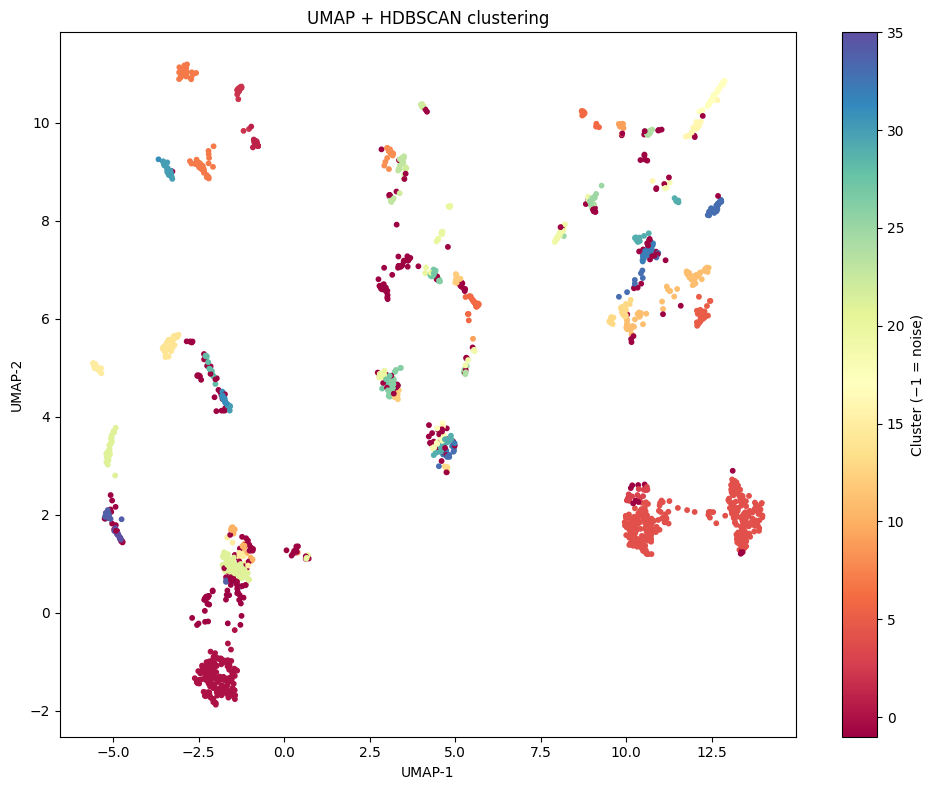

In [33]:
cluster_and_visualize_umap_hdbscan(features_matrix)

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


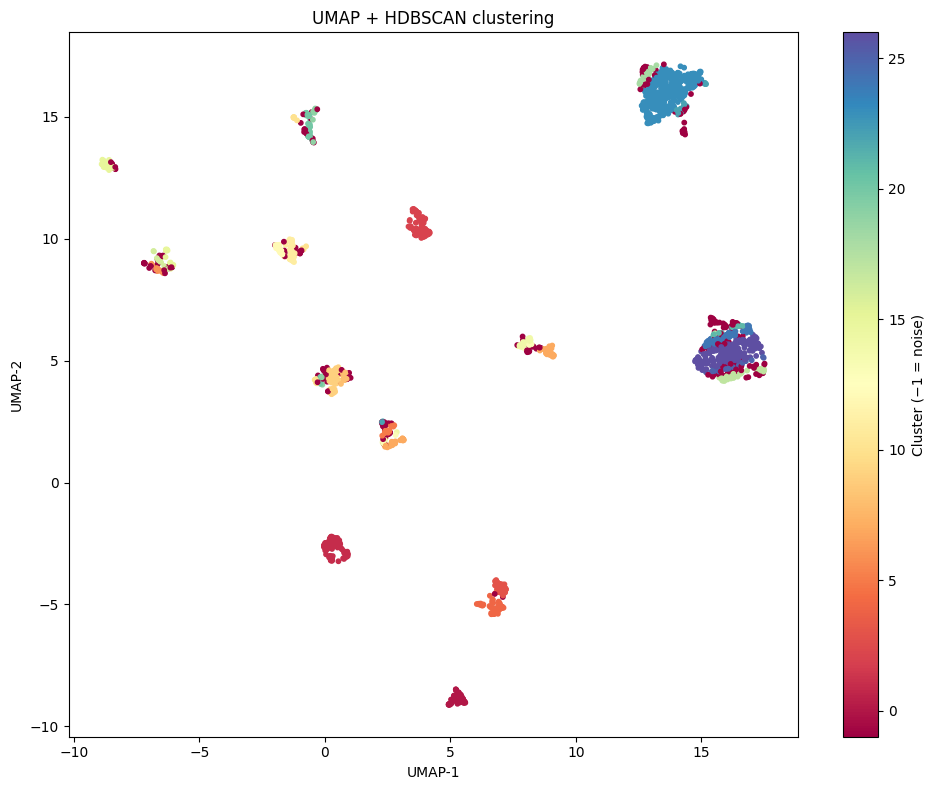

In [34]:
cluster_and_visualize_umap_hdbscan(features_matrix2)

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


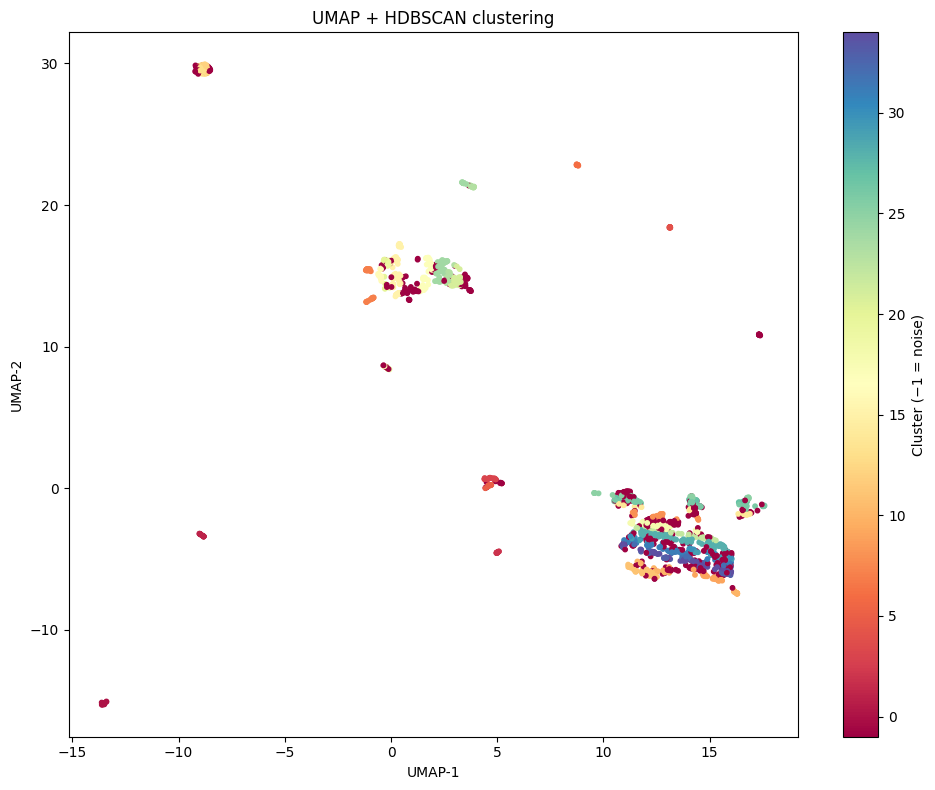

In [35]:
cluster_and_visualize_umap_hdbscan(features_matrix3)

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/bmyakin-eda/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


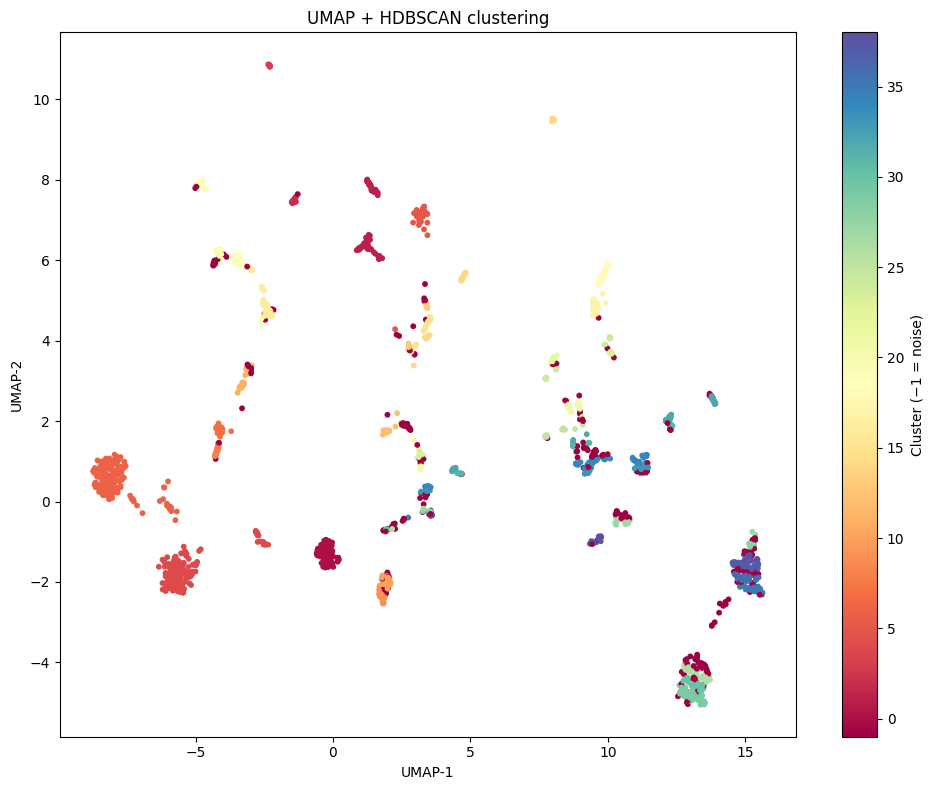

In [36]:
cluster_and_visualize_umap_hdbscan(features_matrix4)